# 📊 Módulo 6: Avaliação de Modelos Preditivos

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

1. **Construir e interpretar a Matriz de Confusão** — entender VP, VN, FP e FN e o que cada célula significa para o negócio
2. **Calcular e comparar métricas de classificação** — Acurácia, Precisão, Recall, F1-Score, Especificidade e AUC-ROC
3. **Analisar curvas de diagnóstico** — ROC, CAP, Lift e KS para avaliar o poder preditivo de um modelo
4. **Aplicar Cross-Validation** — validar modelos de forma robusta usando k-fold estratificado
5. **Escolher a métrica certa** — saber quando priorizar AUC vs F1 vs Acurácia conforme o contexto do problema

## Teoria: Métricas de Avaliação

### Matriz de Confusão

VP = Verdadeiro Positivo, VN = Verdadeiro Negativo, FP = Falso Positivo, FN = Falso Negativo

$$\text{Acurácia} = \frac{VP+VN}{VP+VN+FP+FN}$$

$$\text{Precisão} = \frac{VP}{VP+FP}, \quad \text{Recall} = \frac{VP}{VP+FN}$$

$$F_1 = 2 \cdot \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão}+\text{Recall}}$$

$$\text{Especificidade} = \frac{VN}{VN+FP}$$

---

### AUC-ROC

$$AUC = \int_0^1 TPR(FPR) \, d(FPR)$$

**Accuracy Ratio (AR)** = 2 × AUC − 1

---

### KS (Kolmogorov-Smirnov)

$$KS = \max_t |F_{bons}(t) - F_{maus}(t)|$$

---

### Cross-Validation k-fold

$$CV_k = \frac{1}{k}\sum_{i=1}^k \text{erro}_i$$

---

### Métricas de Regressão

$$MAE = \frac{1}{n}\sum|y_i - \hat{y}_i|, \quad RMSE = \sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$$

$$MAPE = \frac{100}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

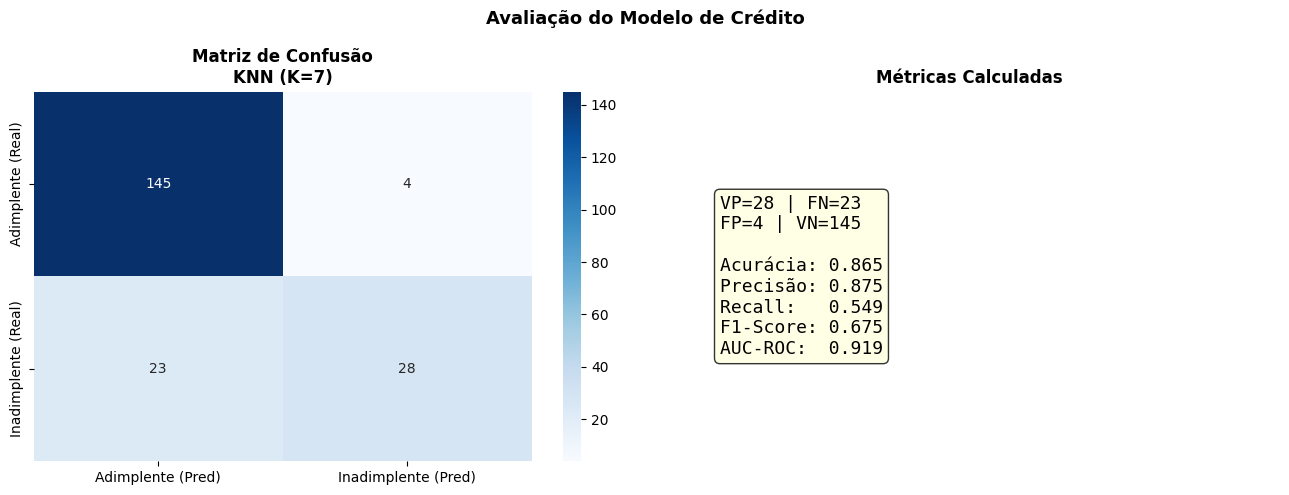


✅ Melhor modelo: KNN (K=7) (AUC = 0.9189)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, roc_curve, auc, precision_recall_curve,
                              classification_report, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Dataset de crédito simulado
X, y = make_classification(n_samples=800, n_features=10, n_informative=6, 
                             n_redundant=2, weights=[0.75, 0.25], random_state=42)
feature_names = ['Score_Hist', 'Renda', 'Divida', 'Emprego_Anos', 'Valor_Emprestimo',
                 'Tx_Utilizacao', 'N_Contas', 'Inadimp_Hist', 'Patrimonio', 'Dependentes']
X_df = pd.DataFrame(X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.25, 
                                                       stratify=y, random_state=42)

modelos = {
    'Regressão Logística': Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(random_state=42))]),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN (K=7)': Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=7))]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]
    cm = confusion_matrix(y_test, y_pred)
    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob, 'cm': cm,
        'auc': roc_auc_score(y_test, y_prob),
        'acc': (y_pred == y_test).mean(),
    }

# Matriz de confusão do melhor modelo
melhor = max(resultados, key=lambda k: resultados[k]['auc'])
cm = resultados[melhor]['cm']
y_pred_melhor = resultados[melhor]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Adimplente (Pred)', 'Inadimplente (Pred)'],
            yticklabels=['Adimplente (Real)', 'Inadimplente (Real)'])
axes[0].set_title(f'Matriz de Confusão\n{melhor}', fontweight='bold')

# Anotações calculadas
vp, fn, fp, vn = cm[1,1], cm[1,0], cm[0,1], cm[0,0]
metricas_texto = (f"VP={vp} | FN={fn}\nFP={fp} | VN={vn}\n\n"
                   f"Acurácia: {(vp+vn)/(vp+vn+fp+fn):.3f}\n"
                   f"Precisão: {vp/(vp+fp):.3f}\n"
                   f"Recall:   {vp/(vp+fn):.3f}\n"
                   f"F1-Score: {2*vp/(2*vp+fp+fn):.3f}\n"
                   f"AUC-ROC:  {resultados[melhor]['auc']:.3f}")
axes[1].text(0.1, 0.5, metricas_texto, transform=axes[1].transAxes, fontsize=13,
             va='center', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].axis('off')
axes[1].set_title('Métricas Calculadas', fontweight='bold', fontsize=12)

plt.suptitle('Avaliação do Modelo de Crédito', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../imagens/06_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Melhor modelo: {melhor} (AUC = {resultados[melhor]['auc']:.4f})")

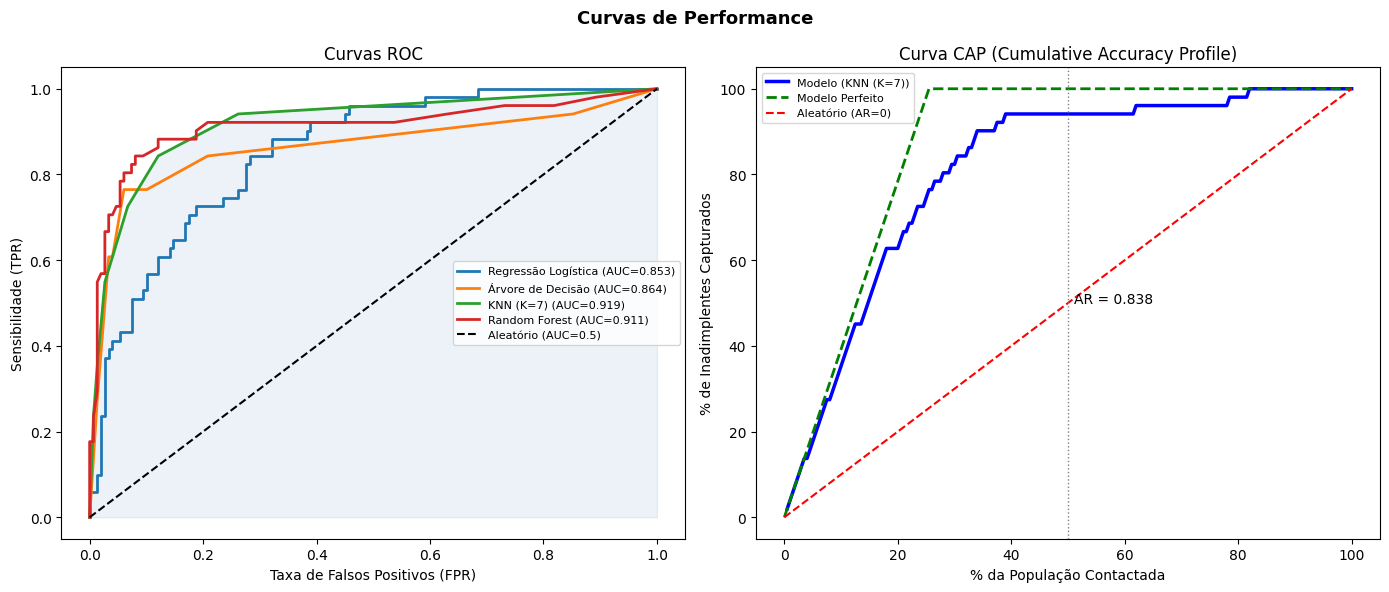

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvas de Performance', fontsize=13, fontweight='bold')

# ROC Curves
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, label=f'{nome} (AUC={res["auc"]:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Aleatório (AUC=0.5)')
axes[0].fill_between(*roc_curve(y_test, resultados[melhor]['y_prob'])[:2], 
                      alpha=0.1, color='steelblue')
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)'); axes[0].set_ylabel('Sensibilidade (TPR)')
axes[0].set_title('Curvas ROC'); axes[0].legend(fontsize=8)

# CAP Curve
ordem = np.argsort(resultados[melhor]['y_prob'])[::-1]
y_sorted = y_test.iloc[ordem].values if hasattr(y_test, 'iloc') else y_test[ordem]
total_pos = y_test.sum()
cap_pct = np.cumsum(y_sorted) / total_pos * 100
pop_pct = np.arange(1, len(y_test)+1) / len(y_test) * 100

axes[1].plot(pop_pct, cap_pct, 'b-', lw=2.5, label=f'Modelo ({melhor})')
axes[1].plot([0, total_pos/len(y_test)*100, 100], [0, 100, 100], 'g--', lw=2, label='Modelo Perfeito')
axes[1].plot([0, 100], [0, 100], 'r--', lw=1.5, label='Aleatório (AR=0)')
ar = resultados[melhor]['auc']*2 - 1
axes[1].axvline(50, color='gray', lw=1, linestyle=':')
axes[1].text(51, 50, f'AR = {ar:.3f}', fontsize=10)
axes[1].set_xlabel('% da População Contactada'); axes[1].set_ylabel('% de Inadimplentes Capturados')
axes[1].set_title('Curva CAP (Cumulative Accuracy Profile)'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../imagens/06_roc_cap.png', dpi=150, bbox_inches='tight')
plt.show()

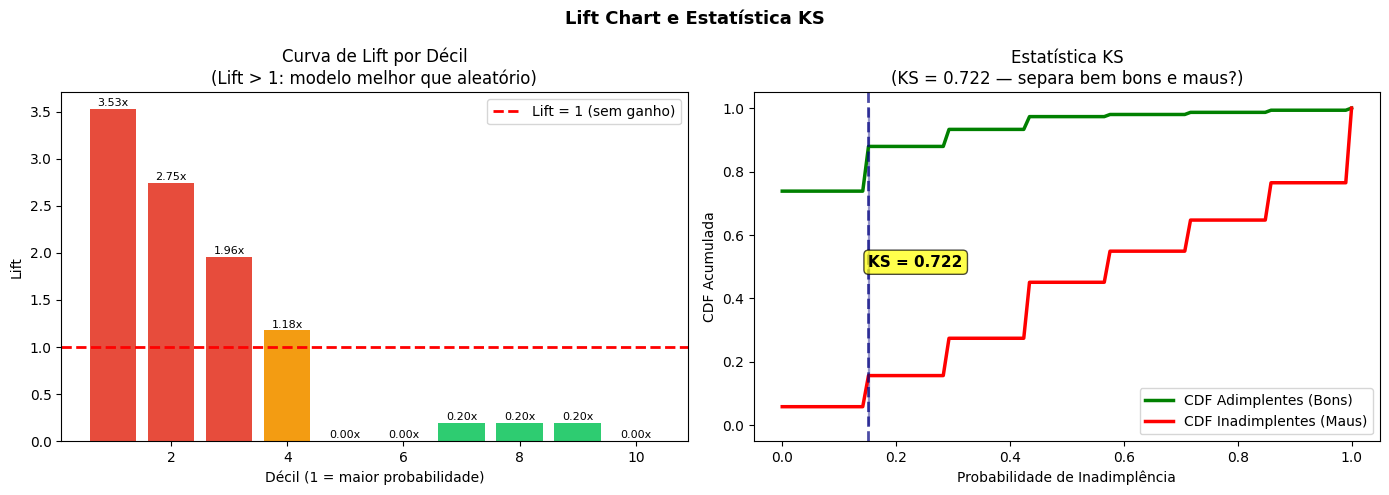


Estatística KS = 0.722
Interpretação: KS > 0.3 = bom | KS > 0.4 = muito bom | KS > 0.5 = excelente


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lift Chart e Estatística KS', fontsize=13, fontweight='bold')

# Lift Curve
n_decis = 10
proba_best = resultados[melhor]['y_prob']
ordem_decis = np.argsort(proba_best)[::-1]
y_ord = y_test.iloc[ordem_decis].values if hasattr(y_test, 'iloc') else y_test[ordem_decis]
n_por_decil = len(y_test) // n_decis
taxa_base = y_test.mean()

lifts = []
for d in range(n_decis):
    decil = y_ord[d*n_por_decil:(d+1)*n_por_decil]
    taxa_decil = decil.mean()
    lifts.append(taxa_decil / taxa_base)

axes[0].bar(range(1, n_decis+1), lifts, color=[('#e74c3c' if v > 1.5 else '#f39c12' if v > 1 else '#2ecc71') for v in lifts])
axes[0].axhline(1, color='red', lw=2, linestyle='--', label='Lift = 1 (sem ganho)')
axes[0].set_xlabel('Décil (1 = maior probabilidade)'); axes[0].set_ylabel('Lift')
axes[0].set_title('Curva de Lift por Décil\n(Lift > 1: modelo melhor que aleatório)')
axes[0].legend()
for i, v in enumerate(lifts):
    axes[0].text(i+1, v+0.03, f'{v:.2f}x', ha='center', fontsize=8)

# KS Statistic
limites = np.linspace(0, 1, 100)
cdf_bons = np.array([(proba_best[y_test==0] <= t).mean() for t in limites])
cdf_maus = np.array([(proba_best[y_test==1] <= t).mean() for t in limites])
ks = np.max(np.abs(cdf_bons - cdf_maus))
t_ks = limites[np.argmax(np.abs(cdf_bons - cdf_maus))]

axes[1].plot(limites, cdf_bons, 'g-', lw=2.5, label='CDF Adimplentes (Bons)')
axes[1].plot(limites, cdf_maus, 'r-', lw=2.5, label='CDF Inadimplentes (Maus)')
axes[1].axvline(t_ks, color='navy', lw=2, linestyle='--', alpha=0.7)
axes[1].annotate(f'KS = {ks:.3f}', xy=(t_ks, 0.5), fontsize=11, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
axes[1].fill_betweenx([0,1], t_ks-0.001, t_ks+0.001, color='navy', alpha=0.3)
axes[1].set_xlabel('Probabilidade de Inadimplência'); axes[1].set_ylabel('CDF Acumulada')
axes[1].set_title(f'Estatística KS\n(KS = {ks:.3f} — separa bem bons e maus?)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/06_lift_ks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nEstatística KS = {ks:.3f}")
print("Interpretação: KS > 0.3 = bom | KS > 0.4 = muito bom | KS > 0.5 = excelente")

,Acurácia,AUC-ROC,CV AUC (média),CV AUC (±dp)
Modelo,,,,
KNN (K=7),0.865,0.9189,0.9274,0.0290
Random Forest,0.895,0.9109,0.9471,0.0228
Árvore de Decisão,0.895,0.8639,0.8662,0.0368
Regressão Logística,0.820,0.8529,0.8526,0.0362


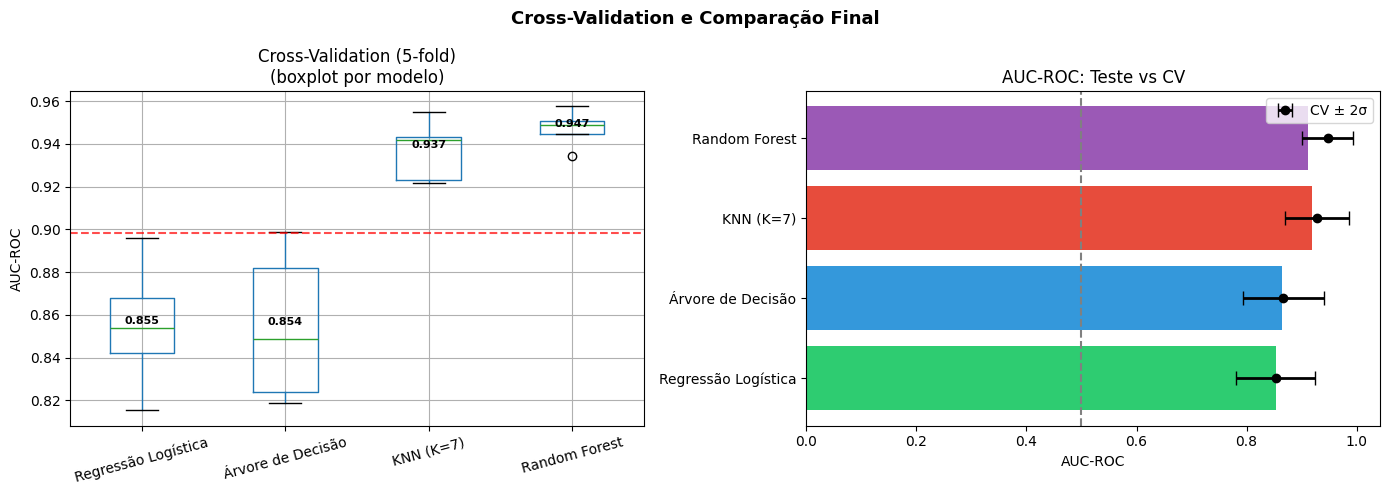

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Validation e Comparação Final', fontsize=13, fontweight='bold')

cv_results = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_df, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                              scoring='roc_auc')
    cv_results[nome] = scores

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=axes[0], rot=15)
axes[0].axhline(cv_df.values.mean(), color='red', lw=1.5, linestyle='--', alpha=0.7)
axes[0].set_ylabel('AUC-ROC'); axes[0].set_title('Cross-Validation (5-fold)\n(boxplot por modelo)')
for i, col in enumerate(cv_df.columns):
    axes[0].text(i+1, cv_df[col].mean(), f'{cv_df[col].mean():.3f}', 
                  ha='center', va='bottom', fontsize=8, fontweight='bold')

# Tabela comparativa final
comp_data = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred_f = modelo.predict(X_test)
    y_prob_f = modelo.predict_proba(X_test)[:,1]
    cv_sc = cross_val_score(modelo, X_df, y, cv=5, scoring='roc_auc')
    comp_data.append({
        'Modelo': nome,
        'Acurácia': (y_pred_f == y_test).mean(),
        'AUC-ROC': roc_auc_score(y_test, y_prob_f),
        'CV AUC (média)': cv_sc.mean(),
        'CV AUC (±dp)': cv_sc.std(),
    })

comp_df = pd.DataFrame(comp_data).set_index('Modelo').round(4)
display(comp_df.sort_values('AUC-ROC', ascending=False))

x = np.arange(len(comp_df))
axes[1].barh(comp_df.index, comp_df['AUC-ROC'], color=['#2ecc71','#3498db','#e74c3c','#9b59b6'])
axes[1].errorbar(comp_df['CV AUC (média)'], range(len(comp_df)),
                  xerr=comp_df['CV AUC (±dp)'] * 2, fmt='ko', capsize=5, lw=2, label='CV ± 2σ')
axes[1].set_xlabel('AUC-ROC'); axes[1].set_title('AUC-ROC: Teste vs CV')
axes[1].axvline(0.5, color='gray', lw=1.5, linestyle='--'); axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/06_cv_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

## Guia de Interpretação das Métricas

### Tabela de Referência Rápida

| Métrica | Fórmula Resumida | Quando Usar | Limitação Principal |
|---|---|---|---|
| **Acurácia** | (VP+VN)/Total | Classes balanceadas | Enganosa com classes desbalanceadas |
| **Precisão** | VP/(VP+FP) | Custo alto do FP (ex: spam) | Ignora os FN |
| **Recall** | VP/(VP+FN) | Custo alto do FN (ex: doença, fraude) | Ignora os FP |
| **F1-Score** | Média harmônica Precisão/Recall | Trade-off equilibrado | Não usa VN |
| **AUC-ROC** | Área sob curva ROC | Comparar modelos, threshold-free | Pode ser otimista com dados muito desbalanceados |
| **KS** | max|CDF_bons - CDF_maus| | Crédito, risco financeiro | Sensível ao ponto de corte |
| **Lift** | Taxa decil / Taxa geral | Marketing, campanhas | Depende do decil escolhido |

---

### Quando Usar Cada Métrica?

**Use AUC-ROC quando:**
- Você precisa comparar múltiplos modelos de forma independente do threshold
- O dataset é moderadamente desbalanceado
- Precisa de uma métrica única e robusta para otimização

**Use F1-Score quando:**
- Existe desequilíbrio entre classes e você precisa equilibrar Precisão e Recall
- O custo de FP e FN são igualmente importantes
- Exemplo: detecção de spam, classificação de documentos

**Use Acurácia quando:**
- As classes são aproximadamente balanceadas
- O custo de todos os erros é similar
- Exemplo: reconhecimento de dígitos (MNIST), classificação de objetos equilibrada

**Use Recall (Sensibilidade) quando:**
- O custo de perder um positivo (FN) é muito alto
- Exemplo: diagnóstico médico, detecção de fraude bancária, alertas de segurança

**Use Precisão quando:**
- O custo de um falso alarme (FP) é muito alto
- Exemplo: filtragem de spam, triagem de currículos, sistemas de recomendação

**Use KS e Lift quando:**
- O contexto é de crédito, propensão de compra ou campanhas de marketing
- Você precisa de uma métrica intuitiva para stakeholders de negócio

---

### Referência: Valores de AUC-ROC

| AUC | Interpretação |
|---|---|
| 0.5 | Modelo aleatório (inútil) |
| 0.5 – 0.7 | Discriminação fraca |
| 0.7 – 0.8 | Discriminação aceitável |
| 0.8 – 0.9 | Discriminação boa |
| > 0.9 | Discriminação excelente |

## Exercícios Propostos

### Exercício 1 — Análise do Trade-off Precisão/Recall
Usando o modelo de crédito treinado neste módulo, altere o threshold de decisão de 0.5 para 0.3 e para 0.7. Compare Precisão, Recall e F1 para cada threshold. Em qual threshold você operaria se fosse um banco querendo minimizar a inadimplência? E se quisesse maximizar a aprovação de crédito?

### Exercício 2 — Métricas em Dataset Desbalanceado
Crie um novo dataset com 95% da classe 0 e 5% da classe 1 (muito desbalanceado). Treine um classificador simples e calcule Acurácia, F1-Score e AUC-ROC. Explique por que a Acurácia pode ser enganosa nesse cenário.

### Exercício 3 — Cross-Validation vs Hold-out
Compare os resultados de 5-fold CV com um único split 80/20 para os 4 modelos deste módulo. Em qual situação a diferença entre CV e hold-out é maior? Qual modelo apresenta maior variância entre os folds?

### Exercício 4 — Curva PR (Precision-Recall)
Plote a curva Precision-Recall (PR) para o melhor modelo. Calcule a AUC-PR. Compare a interpretação da AUC-ROC com a AUC-PR — em qual cenário a AUC-PR é mais informativa?

### Exercício 5 — Análise de Negócio
Suponha que cada falso negativo (inadimplente aprovado) custa R$ 5.000 ao banco, e cada falso positivo (adimplente reprovado) custa R$ 200 em perda de receita. Calcule o custo total para cada um dos 4 modelos e identifique o "melhor" modelo sob essa perspectiva de custo de negócio.